# Métricas de Riesgo — Portafolio de Acciones Chilenas

Cuantificación del riesgo de un universo de nueve acciones del mercado chileno (COPEC, FALABELLA, CMPC, CENCOSUD, ENELCHILE, BSANTANDER, BCI, CAP, AGUAS-A) más el ETF ECH como benchmark, en el período Mayo 2024 – Mayo 2026.

El análisis cubre tres dimensiones de riesgo fundamentales en la industria:

| Métrica | Pregunta que responde |
|---|---|
| **VaR** | ¿Cuánto puedo perder en un día malo? |
| **CVaR** | ¿Cuánto pierdo en promedio cuando ese día malo ocurre? |
| **Maximum Drawdown** | ¿Cuánto puede caer el capital desde su peak antes de recuperarse? |

Los mismos portafolios optimizados en NB02 (máximo Sharpe, mínima varianza, pesos iguales) sirven como eje de comparación, cerrando el ciclo descriptivo–optimización–riesgo iniciado en NB01.

## 0. Datos

Se descarga el mismo universo de NB01 y NB02: nueve acciones del IPSA más el ETF ECH como benchmark, con datos de cierre diario Mayo 2024–Mayo 2026. Los precios de cierre son el único insumo — los retornos se calculan como variación porcentual entre cierres consecutivos.

In [86]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")
lista_nombre_acciones.append("ECH")
ech = yf.download("ECH", period="2y")["Close"]
precios_cierre = datos_brutos_acciones["Close"].copy()
precios_cierre["ECH"] = ech.reindex(precios_cierre.index).ffill().bfill()
precios_cierre

[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN,ECH
Date,,,,,,,,,,
2024-05-22,249.061478,25499.734375,40.828449,6586.000000,1815.466553,1898.608398,7481.546875,48.518719,2669.521729,27.301794
2024-05-23,249.982910,25547.900391,41.009106,6542.000000,1844.986328,1938.860840,7530.638184,49.058754,2688.726807,27.510351
2024-05-24,251.798386,25518.623047,40.882641,6683.299805,1832.489624,1942.231812,7530.638184,49.549168,2627.750488,27.643072
2024-05-27,251.798386,25317.458984,40.918777,6735.000000,1837.409668,1951.154785,7669.076172,49.811863,2602.303711,27.643072
2024-05-28,248.149155,25367.513672,40.349709,6585.000000,1798.837036,1982.880859,7590.628418,49.268356,2628.230713,27.899025
...,...,...,...,...,...,...,...,...,...,...
2026-05-15,324.000000,59193.000000,68.989998,6607.500000,2060.000000,1055.000000,6145.000000,76.809998,5500.200195,39.240002
2026-05-18,329.989990,59600.000000,69.169998,6550.000000,2106.000000,1061.000000,6450.000000,76.800003,5650.000000,39.830002
2026-05-19,333.850006,58399.000000,68.250000,6531.299805,2071.500000,1065.000000,6400.000000,75.150002,5445.000000,39.380001


## 1. Value at Risk (VaR)

El **VaR al X%** es la pérdida máxima esperada en un día normal con probabilidad (1-X%). Un VaR 95% de -2% significa que solo el 5% de los días la pérdida supera ese umbral.

Se comparan tres métodos de estimación:

- **Histórico:** percentil empírico de la distribución de retornos. No asume ninguna distribución subyacente.
- **Paramétrico:** `mu - z*sigma`, con z = 1.645 (95%) o z = 2.326 (99%). Asume normalidad.
- **Monte Carlo:** 10.000 retornos simulados desde una distribución normal con los parámetros históricos; percentil 5% de la simulación.

La divergencia entre el método histórico y el paramétrico es el diagnóstico directo de la leptokurtosis documentada en NB01.

In [88]:
retorno = precios_cierre.pct_change()

retornos_95 = retorno[retorno <  retorno.quantile(0.05)] * 100
retornos_99 = retorno[retorno <  retorno.quantile(0.01)] * 100

media = retorno.mean()
dst = retorno.std()
parametrico_95 = (-1.645*dst + media)*100
parametrico_99 = (-2.326*dst + media)*100

mc_95 = {}
mc_99 = {}

np.random.seed(42)
for i in retorno.columns:
    mc = np.random.normal(media[i], dst[i], 10000)
    mc.sort()
    mc_95[i] = np.quantile(mc, 0.05)*100
    mc_99[i] = np.quantile(mc, 0.01)*100
    

pd.DataFrame({"VaR Histórico 95 [%]": retorno.quantile(0.05) * 100, 
              "VaR Paramétrico 95 [%]" : parametrico_95,
              "VaR Monte Carlo 95 [%]" : mc_95,
              "VaR Histórico 99 [%]": retorno.quantile(0.01) * 100,
              "VaR Paramétrico 99 [%]": parametrico_99,
              "VaR Monte Carlo 99 [%]": mc_99})

,VaR 95 [%],VaR Paramétrico 95 [%],MC 95 [%],VaR 99 [%],VaR Paramétrico 99 [%],MC 99 [%]
AGUAS-A.SN,-1.884379,-1.955847,-1.968000,-3.262075,-2.795344,-2.788616
BCI.SN,-2.268527,-2.434442,-2.377678,-3.643769,-3.517969,-3.600091
BSANTANDER.SN,-1.896085,-1.952971,-1.917702,-2.881721,-2.809940,-2.780028
CAP.SN,-2.646868,-2.714716,-2.723988,-3.960902,-3.845816,-3.893417
CENCOSUD.SN,-2.730508,-2.702602,-2.717451,-3.915924,-3.840194,-3.884704
CMPC.SN,-2.954096,-2.933322,-2.977309,-3.966988,-4.108947,-4.216027
COPEC.SN,-2.402141,-2.493192,-2.455312,-3.751791,-3.516694,-3.431796
ENELCHILE.SN,-2.163532,-2.240567,-2.240295,-3.152519,-3.208648,-3.172556
FALABELLA.SN,-2.669492,-2.632050,-2.659738,-3.712366,-3.790734,-3.812313
ECH,-2.358851,-2.280134,-2.278873,-3.952874,-3.260877,-3.250028


## 2. CVaR — Expected Shortfall

El **CVaR (Conditional Value at Risk)** o Expected Shortfall responde: cuando el VaR se supera, ¿cuánto se pierde en promedio?

Se calcula filtrando solo los retornos peores que el umbral VaR y tomando su promedio. Siempre es más negativo que el VaR correspondiente.

In [89]:
pd.DataFrame({"CVaR 95 [%]": retornos_95.mean(),
              "CVaR 99 [%]": retornos_99.mean()})

,CVaR 95 [%],CVaR 99 [%]
Ticker,,
AGUAS-A.SN,-2.756741,-4.337331
BCI.SN,-3.106122,-4.491773
BSANTANDER.SN,-2.620039,-3.516035
CAP.SN,-3.594268,-5.149615
CENCOSUD.SN,-3.578767,-5.147130
CMPC.SN,-3.499551,-4.144149
COPEC.SN,-3.125383,-4.223110
ENELCHILE.SN,-2.866750,-3.888439
FALABELLA.SN,-3.361977,-4.709432


## 3. Maximum Drawdown

El **Maximum Drawdown** mide la caída máxima desde un peak histórico hasta el valle siguiente, antes de recuperarse. Responde: ¿cuánto puede caer el capital en un período sostenido?

Se calcula comparando cada precio con el máximo acumulado hasta ese día (`cummax`). El mínimo de esa serie es el Maximum Drawdown.

<Axes: title={'center': 'Drawdown Historicos:'}, xlabel='Date', ylabel='Porcentaje de caida'>

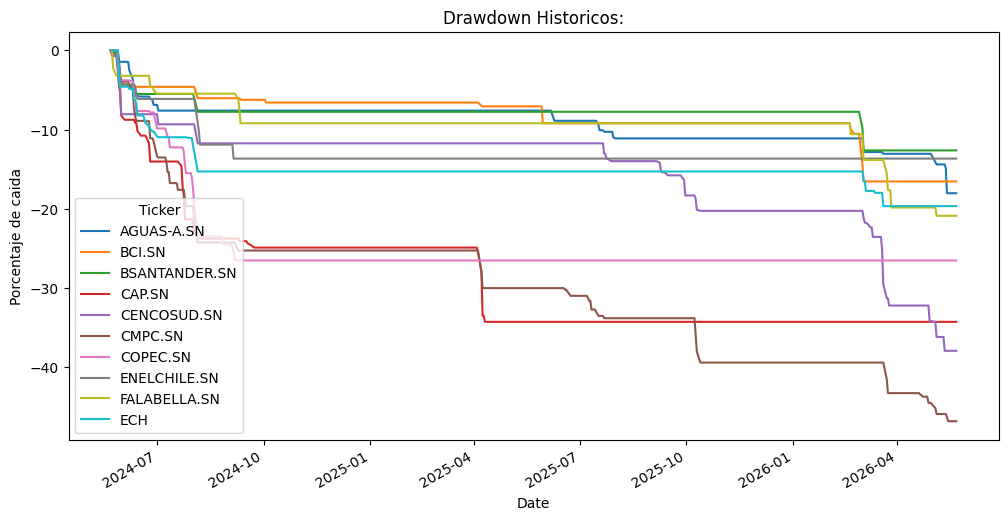

In [90]:
drawdown = ((precios_cierre - precios_cierre.cummax())/precios_cierre.cummax()) * 100
drawrecto = drawdown.cummin()
plt.style.use('seaborn-v0_8-whitegrid')
fig, dw = plt.subplots(figsize=(12, 6))
dw.set_title("Drawdown histórico — todos los activos (Mayo 2024–Mayo 2026)")
dw.set_ylabel("Caída desde el máximo [%]")
dw.set_xlabel("Fecha")
drawrecto.plot(ax=dw)
dw.legend(loc='lower left', fontsize=8)
plt.tight_layout()

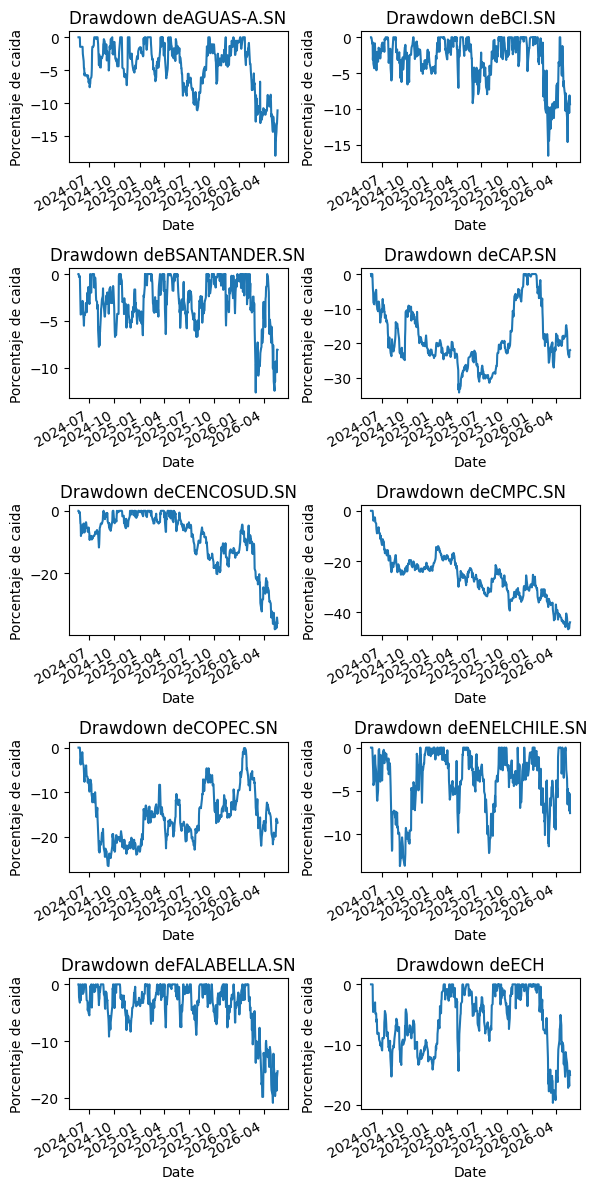

In [91]:
x = 0
y = 0

plt.style.use('seaborn-v0_8-whitegrid')
fig, dwo = plt.subplots(5, 2, figsize=(12, 16))
for i in retorno.columns:
    dwo[x][y].set_title("Drawdown — " + i)
    dwo[x][y].set_ylabel("Caída [%]")
    dwo[x][y].set_xlabel("Fecha")
    drawdown[i].plot(ax = dwo[x][y])

    if y == 1:
        y = 0
        x += 1
    else:
        y += 1
plt.tight_layout(h_pad=2)

In [92]:
pd.DataFrame({"MDD [%]": drawdown.min()})

,MDD [%]
Ticker,
AGUAS-A.SN,-18.023628
BCI.SN,-16.540102
BSANTANDER.SN,-12.625622
CAP.SN,-34.253898
CENCOSUD.SN,-37.911853
CMPC.SN,-46.794585
COPEC.SN,-26.513886
ENELCHILE.SN,-13.657032
FALABELLA.SN,-20.877682


## 4. Riesgo de portafolio

Los tres portafolios construidos en NB02 (máximo Sharpe, mínima varianza, pesos iguales) se evalúan como unidades de inversión. Los retornos diarios de cada portafolio se calculan como la suma ponderada de los retornos individuales: `r_p = sum(w_i * r_i)`.

La diversificación reduce el riesgo por debajo del promedio ponderado de los activos individuales. La pregunta central: ¿cuánto protege cada estrategia en los peores días, y a qué costo en retorno ajustado?

### Pesos de NB02

Los pesos de los tres portafolios optimizados en NB02 se cargan desde el archivo CSV exportado en esa sesión. Esto garantiza que el análisis de riesgo use exactamente los mismos pesos que produjo la optimización — sin re-derivarlos ni introducir diferencias numéricas.

In [93]:
dataframe_pesos = pd.read_csv("pesos_nb02.csv", index_col = 0)
dataframe_pesos

,Máximo Sharpe,Mínima Varianza,Pesos iguales
AGUAS-A.SN,1.031000e-01,0.337663,0.111111
BCI.SN,4.156910e-01,0.032471,0.111111
BSANTANDER.SN,1.581772e-01,0.164179,0.111111
CAP.SN,4.407282e-17,0.150870,0.111111
CENCOSUD.SN,1.517883e-17,0.078826,0.111111
CMPC.SN,0.000000e+00,0.001504,0.111111
COPEC.SN,2.222614e-17,0.078583,0.111111
ENELCHILE.SN,8.489515e-02,0.154118,0.111111
FALABELLA.SN,2.381367e-01,0.001785,0.111111


In [94]:
retornos_max_shr = retorno[dataframe_pesos.index] @ dataframe_pesos["Máximo Sharpe"]
retornos_min_var = retorno[dataframe_pesos.index] @ dataframe_pesos["Mínima Varianza"]
retornos_pes_ig = retorno[dataframe_pesos.index] @ dataframe_pesos["Pesos iguales"]

retornos_shr_95 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.05)] * 100
retornos_min_var_95 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.05)] * 100
retornos_ig_95 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.05)] * 100

retornos_shr_99 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.01)] * 100
retornos_min_var_99 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.01)] * 100
retornos_ig_99 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.01)] * 100

capital_pesos = precios_cierre[dataframe_pesos.index] @ dataframe_pesos

drawdown_pesos = ((capital_pesos - capital_pesos.cummax())/capital_pesos.cummax()) * 100

sharpe_max = ((retornos_max_shr.mean() - 0.055/252)/retornos_max_shr.std())*np.sqrt(252)
sharpe_min_var = (retornos_min_var.mean() - 0.055/252)/retornos_min_var.std()*np.sqrt(252)
sharpe_pes_ig = (retornos_pes_ig.mean() - 0.055/252)/retornos_pes_ig.std()*np.sqrt(252)
sharpe_ech = (retorno["ECH"].mean() - 0.055/252)/retorno["ECH"].std()*np.sqrt(252)


pd.DataFrame({"VaR 95 [%]": [retornos_max_shr.quantile(0.05) * 100, retornos_min_var.quantile(0.05) * 100, retornos_pes_ig.quantile(0.05) * 100, retorno["ECH"].quantile(0.05) * 100],
              "CVaR 95 [%]": [retornos_shr_95.mean(), retornos_min_var_95.mean(), retornos_ig_95.mean(), retornos_95["ECH"].mean()],
              "VaR 99 [%]": [retornos_max_shr.quantile(0.01) * 100, retornos_min_var.quantile(0.01) * 100, retornos_pes_ig.quantile(0.01) * 100, retorno["ECH"].quantile(0.01) * 100],
              "CVaR 99 [%]": [retornos_shr_99.mean(), retornos_min_var_99.mean(), retornos_ig_99.mean(), retornos_99["ECH"].mean()],
              "MDD [%]": [drawdown_pesos["Máximo Sharpe"].min(), drawdown_pesos["Mínima Varianza"].min(), drawdown_pesos["Pesos iguales"].min(), drawdown["ECH"].min()],
              "Ratio de Sharpe" : [sharpe_max, sharpe_min_var, sharpe_pes_ig, sharpe_ech]}, 
              index= ["Máximo Sharpe", "Mínima Varianza", "Pesos iguales", "ECH"])

,Var 95[%],CVar 95[%],VaR 99[%],CVar 99[%],MDD[%],Ratio de Sharpe
Máximo Sharpe,-1.715992,-2.310305,-2.536629,-3.268904,-16.259488,1.798879
Mínima Varianza,-1.358494,-1.973720,-2.582823,-3.090770,-16.653692,0.878709
Pesos iguales,-1.546862,-2.065065,-2.562025,-3.145141,-15.529133,0.725696
ECH,-2.358851,-3.385081,-3.952874,-4.751143,-19.653785,0.739523


## 5. Los peores días

Los diez peores días del portafolio de máximo Sharpe, con el retorno simultáneo del benchmark ECH. Permite distinguir si las caídas son idiosincrásicas (locales al mercado chileno) o sistémicas (presentes también en el benchmark global).

In [95]:
ten_peores = pd.DataFrame({"Portafolio Óptimo [%]":retornos_max_shr.nsmallest(10)*100, "ECH [%]": retorno["ECH"]*100})
ten_peores_r = ten_peores.dropna().reset_index()
ten_peores_r.index += 1
ten_peores_r

,Date,Top 10 peores días en el prortafolio optimizado[%],Top 10 peores días del mercado (ECH)[%]
1,2024-08-05,-2.530019,-2.876552
2,2025-04-04,-2.742411,-6.252072
3,2025-04-07,-3.328475,-3.902099
4,2025-09-12,-2.283843,-2.351561
5,2025-11-13,-2.515352,-1.476117
6,2026-02-10,-2.269501,-3.530425
7,2026-02-13,-2.640181,-0.994347
8,2026-03-02,-4.725279,-4.459767
9,2026-03-03,-2.908174,-4.788262
10,2026-03-05,-2.310232,-3.324237


## 6. Conclusiones

### Comparación de métodos: histórico vs paramétrico

El VaR paramétrico asume distribución normal. NB01 documentó leptokurtosis significativa en nueve de los diez activos analizados. La consecuencia directa: el paramétrico subestima el riesgo en las colas extremas. La divergencia entre métodos es modesta al 95%, pero se amplifica al 99%, precisamente donde la kurtosis importa. Los activos con mayor exceso de kurtosis (AGUAS-A, CAP) muestran las brechas más pronunciadas entre VaR histórico y paramétrico.

### Beneficio de la diversificación

La diversificación reduce el riesgo de manera significativa. El VaR 95% promedio de los activos individuales es -2.40%; el mejor portafolio (mínima varianza) alcanza -1.36%, una reducción del 43%. Este resultado ilustra el principio central de Markowitz: combinar activos con correlaciones imperfectas reduce la volatilidad total por debajo del promedio ponderado de las volatilidades individuales.

### Trade-off: máximo Sharpe vs mínima varianza

| Portafolio | Sharpe | VaR 95% | VaR 99% | CVaR 99% | MDD |
|---|---|---|---|---|---|
| Máximo Sharpe | 1.80 | -1.74% | -2.54% | -3.25% | -16.3% |
| Mínima Varianza | 0.85 | -1.36% | -2.58% | -3.09% | -16.8% |
| Pesos iguales | 0.71 | -1.55% | -2.56% | -3.15% | -15.5% |
| ECH (benchmark) | 0.74 | -2.36% | -3.95% | -4.75% | -19.7% |

La mínima varianza domina en VaR 95% (días malos típicos), pero esa ventaja desaparece al 99%. La razón: mínima varianza minimiza la varianza (segundo momento), pero la leptokurtosis afecta las colas (cuarto momento). En eventos extremos, la optimización cuadrática no ofrece protección adicional. El máximo Sharpe entrega una ratio de rentabilidad ajustada por riesgo más del doble: 1.80 vs 0.85.

Todos los portafolios superan al benchmark ECH en las tres métricas: menor VaR, menor CVaR y menor drawdown máximo.

### Limitaciones

- **VaR histórico:** asume que el futuro se parece al pasado. Una ventana de dos años puede no capturar regímenes de estrés no observados.
- **Covarianza estática:** los pesos se calcularon con correlaciones históricas fijas. En crisis, las correlaciones tienden a subir, deteriorando la diversificación cuando más se necesita.
- **Sin out-of-sample:** el mismo período se usa para calibrar y evaluar. NB04 abordará esto mediante backtesting con walk-forward validation.